<a href="https://colab.research.google.com/github/mate-teglas/Introduction-to-machine-learning---Final-Project---TM-NZS-/blob/main/Age.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://susanqq.github.io/UTKFace/
# utilizes UTK dataset for age recognition (& gender)

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from tensorflow import keras
from keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, SeparableConv2D
from keras.regularizers import l2
import glob

In [ ]:
#extract data from the drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!unzip -q "/content/drive/MyDrive/IML/age.zip" -d "/content/dataset/"

Mounted at /content/drive


In [ ]:
# Gather all file paths from the loose folder
image_paths = glob.glob("/content/dataset/**/*.jpg", recursive=True)

clean_image_paths = []
# Filter bad files to avoid later crashes
for path in image_paths:
    filename = os.path.basename(path)

    # Skip Mac system files, hidden files, or files with double underscores
    if "__" in filename or filename.startswith("."):
        continue

    # Ensure the file follows the format [age]_[gender]_[etc].jpg (at least 2 underscores)
    if len(filename.split('_')) >= 3:
        clean_image_paths.append(path)

image_paths = clean_image_paths
# Shuffle the raw file path strings deterministically before splitting
np.random.seed(123)
np.random.shuffle(image_paths)

total_images = len(image_paths)
split_index = int(total_images * 0.8)

# Split the list of strings
val_paths = image_paths[:split_index]
test_paths = image_paths[split_index:]

print(f"Total dataset: {total_images} images")
print(f"\tValidation split: {len(val_paths)} images")
print(f"\tTesting split: {len(test_paths)} images")

train_ages = []
for path in val_paths:
    filename = os.path.basename(path)
    age = float(filename.split('_')[0])
    train_ages.append(age)

train_ages = np.array(train_ages)

bins = [0, 5, 20, 40, 60, 70, 80, 100, 120]
counts, edges = np.histogram(train_ages, bins=bins)

# 1. Standard Balanced Weight Formula
total_samples = np.sum(counts)
num_valid_bins = np.sum(counts > 0) # Only count bins that actually contain images

# Calculate weight: Total / (Number of Classes * Count in Class)
# We add +1.0 to the denominator to prevent division by zero for empty bins
weights_per_bin = total_samples / (num_valid_bins * (counts + 1.0))

# 2. THE CRUCIAL STEP: Cap the extreme weights
# We restrict the network from multiplying any error by more than 10x or less than 0.1x.
# This prevents gradient explosion while still strongly fighting the imbalance.

weights_per_bin = np.clip(weights_per_bin, 0.05, 15.0)
weights_per_bin[0] = 1.5
weights_per_bin[1] = 1.46
print("Smoothed & Capped Weights:")
for i in range(len(counts)):
    print(f"Age {edges[i]:.0f}-{edges[i+1]:.0f} | Count: {counts[i]:>5} | Multiplier: {weights_per_bin[i]:.2f}x")

tf_weights = tf.constant(weights_per_bin, dtype=tf.float32)

Total dataset: 24105 images
	Validation split: 19284 images
	Testing split: 4821 images
Smoothed & Capped Weights:
Age 0-5 | Count:  1923 | Multiplier: 1.50x
Age 5-20 | Count:  2011 | Multiplier: 1.46x
Age 20-40 | Count:  9511 | Multiplier: 0.25x
Age 40-60 | Count:  3630 | Multiplier: 0.66x
Age 60-70 | Count:  1070 | Multiplier: 2.25x
Age 70-80 | Count:   566 | Multiplier: 4.25x
Age 80-100 | Count:   549 | Multiplier: 4.38x
Age 100-120 | Count:    24 | Multiplier: 15.00x


In [ ]:
# Map functions
def load_with_weights(file_path):
    # --- 1. Load Image ---
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [128, 128])
    img = img / 255.0

    # Randomly flip 50% of the images horizontally
    img = tf.image.random_flip_left_right(img)
    # Mildly shift the brightness so it learns different lighting conditions
    img = tf.image.random_brightness(img, max_delta=0.1)

    # --- 2. Extract Labels ---
    filename = tf.strings.split(file_path, os.sep)[-1]
    parts = tf.strings.split(filename, '_')
    age = tf.strings.to_number(parts[0], out_type=tf.float32)
    gender = tf.strings.to_number(parts[1], out_type=tf.float32)

    # --- 3. Bin/Weight Calculation ---
    bin_idx = tf.cast(age / 10.0, tf.int32)
    max_idx = tf.shape(tf_weights)[0] - 1
    bin_idx = tf.clip_by_value(bin_idx, 0, max_idx)

    age_weight = tf.gather(tf_weights, bin_idx)
    gender_weight = tf.constant(1.0, dtype=tf.float32)

    return img, (gender, age), (gender_weight, age_weight)

def load_without_weights(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [128, 128])
    img = img / 255.0

    filename = tf.strings.split(file_path, os.sep)[-1]
    parts = tf.strings.split(filename, '_')
    age = tf.strings.to_number(parts[0], out_type=tf.float32)
    gender = tf.strings.to_number(parts[1], out_type=tf.float32)

    return img, (gender, age)

In [ ]:
# --- Build Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

valid_dataset = tf.data.Dataset.from_tensor_slices(val_paths)
valid_dataset = valid_dataset.shuffle(buffer_size=1000)
valid_dataset = valid_dataset.map(load_with_weights, num_parallel_calls=AUTOTUNE)
valid_dataset = valid_dataset.batch(32).cache('/content/val_disk_cache').prefetch(buffer_size=AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(test_paths)
test_dataset = test_dataset.map(load_without_weights, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.batch(32).cache('/content/test_disk_cache').prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Multi output model
inputs = Input(shape=(128, 128, 3))

# Data Augmentation (Runs on GPU automatically during training, disabled during testing)
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
], name="augmentation_layer")

augmented = data_augmentation(inputs)

# --- SHARED TRUNK: General Face Geometry ---
x = Conv2D(32, (3, 3), padding='same', activation='relu')(augmented)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = SeparableConv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = SeparableConv2D(128, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
shared_features = MaxPooling2D(pool_size=(2,2))(x)

# --- BRANCH 1: GENDER CLASSIFICATION ---
g = SeparableConv2D(128, (3, 3), padding='same', activation='relu')(shared_features)
g = BatchNormalization()(g)
g = MaxPooling2D(pool_size=(2,2))(g)

g = GlobalAveragePooling2D()(g)
g = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(g)
g = Dropout(0.3)(g)
gender_out = Dense(1, activation='sigmoid', name='gender_out')(g)

# --- BRANCH 2: AGE REGRESSION ---
a = SeparableConv2D(256, (3, 3), padding='same', activation='relu')(shared_features)
a = BatchNormalization()(a)
a = MaxPooling2D(pool_size=(2,2))(a)

a = GlobalAveragePooling2D()(a)
a = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(a)
a = Dropout(0.4)(a)
a = Dense(64, activation='relu')(a)
age_out = Dense(1, activation='relu', name='age_out')(a)

# Create the model
model = keras.Model(inputs=inputs, outputs=[gender_out, age_out])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_layer  │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ augmentation_lay… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 64,    │      2,400 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 32, 32,    │      8,896 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 16, 16,    │     34,176 │ max_pooling2d_2[… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 16, 16,    │     17,664 │ max_pooling2d_2[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 128) │          0 │ batch_normalizat

 Total params: 116,002 (453.13 KB)

 Trainable params: 114,786 (448.38 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss={
        'gender_out': 'binary_crossentropy',
        'age_out': 'mse'
    },
    loss_weights={
        'gender_out': 10.0,
        'age_out': 1.0
    },
    metrics={
        'gender_out': 'accuracy',
        'age_out': 'mae'  # Keep MAE here so you can still read the 'years off' cleanly
    }
)

history = model.fit(
    valid_dataset,
    epochs=25,
    validation_data=test_dataset
)

Epoch 1/25
603/603 ━━━━━━━━━━━━━━━━━━━━ 106s 154ms/step - age_out_loss: 1619.2489 - age_out_mae: 24.1210 - gender_out_accuracy: 0.6242 - gender_out_loss: 0.6501 - loss: 1626.5500 - val_age_out_loss: 453.0838 - val_age_out_mae: 17.4347 - val_gender_out_accuracy: 0.6694 - val_gender_out_loss: 0.6141 - val_loss: 459.5564
Epoch 2/25
603/603 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - age_out_loss: 1348.0728 - age_out_mae: 22.3827 - gender_out_accuracy: 0.6800 - gender_out_loss: 0.5934 - loss: 1354.6904 - val_age_out_loss: 447.7514 - val_age_out_mae: 17.2038 - val_gender_out_accuracy: 0.6078 - val_gender_out_loss: 0.6974 - val_loss: 455.0425
Epoch 3/25
603/603 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - age_out_loss: 1227.2472 - age_out_mae: 21.0288 - gender_out_accuracy: 0.7033 - gender_out_loss: 0.5634 - loss: 1233.5260 - val_age_out_loss: 521.6642 - val_age_out_mae: 18.2580 - val_gender_out_accuracy: 0.7206 - val_gender_out_loss: 0.5407 - val_loss: 527.4279
Epoch 4/25
603/603 ━━━━━━━━━━━━━━━━━━━━ 32s 

In [ ]:
model.save('/content/drive/MyDrive/IML/age_classification_new_mae10.keras')

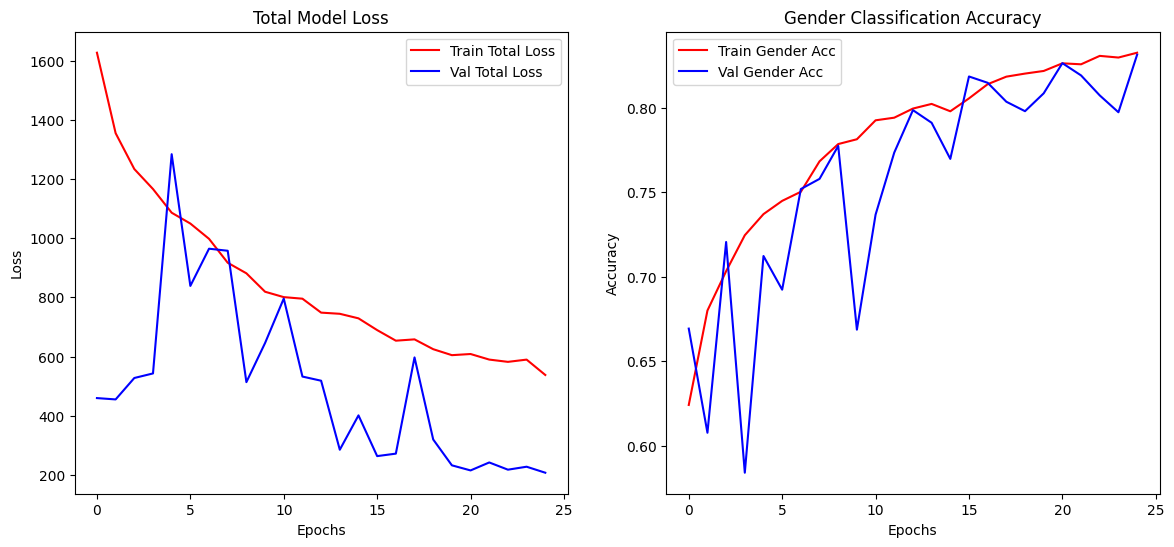

In [ ]:
# Create a wide figure to hold 3 subplots side-by-side
plt.figure(figsize=(14,6))

# --- Plot 1: Total Loss Progression ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='red', label='Train Total Loss')
plt.plot(history.history['val_loss'], color='blue', label='Val Total Loss')
plt.title('Total Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Plot 2: Gender Classification Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history.history['gender_out_accuracy'], color='red', label='Train Gender Acc')
plt.plot(history.history['val_gender_out_accuracy'], color='blue', label='Val Gender Acc')
plt.title('Gender Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


Extracting testing data for Age Analysis...


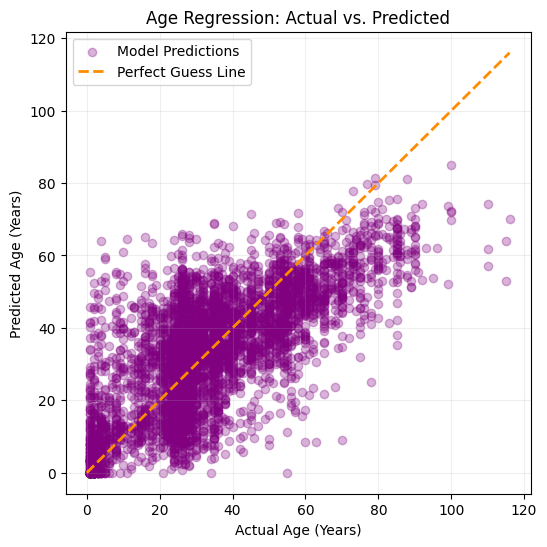

Final Test Evaluation: On average, the model is off by ±10.94 years.


In [ ]:
y_true_age = []
y_pred_age = []

print("Extracting testing data for Age Analysis...")

for images, targets in test_dataset:
    # 1. Extract true numerical age from the target dictionary
    y_true_age.extend(targets[1].numpy())

    # 2. Extract predicted age (Index 1 is the linear age output head)
    preds = model.predict(images, verbose=0)
    age_predictions = preds[1].flatten()
    y_pred_age.extend(age_predictions)

y_true_age = np.array(y_true_age)
y_pred_age = np.array(y_pred_age)

# Plotting Actual vs Predicted Age
plt.figure(figsize=(6, 6))
plt.scatter(y_true_age, y_pred_age, alpha=0.3, color='purple', label='Model Predictions')

# Draw a perfect diagonal reference line (y = x)
max_age = int(max(max(y_true_age), max(y_pred_age)))
plt.plot([0, max_age], [0, max_age], color='darkorange', linestyle='--', lw=2, label='Perfect Guess Line')

plt.xlabel('Actual Age (Years)')
plt.ylabel('Predicted Age (Years)')
plt.title('Age Regression: Actual vs. Predicted')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Print the overall final test MAE score
final_mae = np.mean(np.abs(y_true_age - y_pred_age))
print(f"Final Test Evaluation: On average, the model is off by ±{final_mae:.2f} years.")

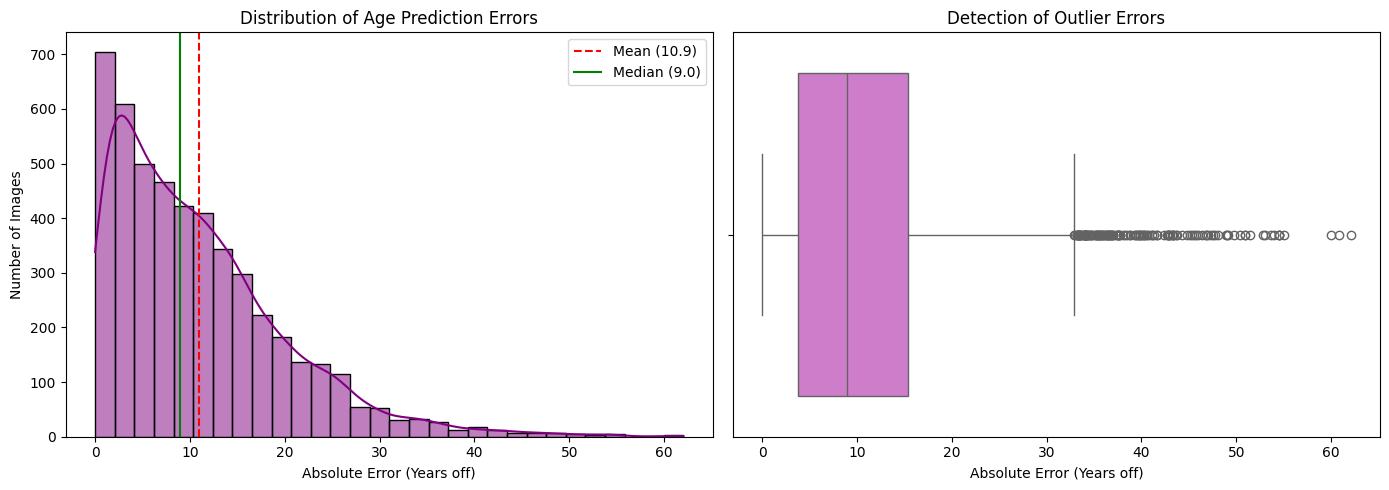

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate absolute errors for every single image
absolute_errors = np.abs(y_true_age - y_pred_age)

plt.figure(figsize=(14, 5))

# Plot 1: Histogram of Error Distribution
plt.subplot(1, 2, 1)
sns.histplot(absolute_errors, kde=True, color='purple', bins=30)
plt.axvline(np.mean(absolute_errors), color='red', linestyle='--', label=f'Mean ({np.mean(absolute_errors):.1f})')
plt.axvline(np.median(absolute_errors), color='green', linestyle='-', label=f'Median ({np.median(absolute_errors):.1f})')
plt.xlabel('Absolute Error (Years off)')
plt.ylabel('Number of Images')
plt.title('Distribution of Age Prediction Errors')
plt.legend()

# Plot 2: Boxplot to highlight Outliers explicitly
plt.subplot(1, 2, 2)
sns.boxplot(x=absolute_errors, color='orchid')
plt.xlabel('Absolute Error (Years off)')
plt.title('Detection of Outlier Errors')

plt.tight_layout()
plt.show()

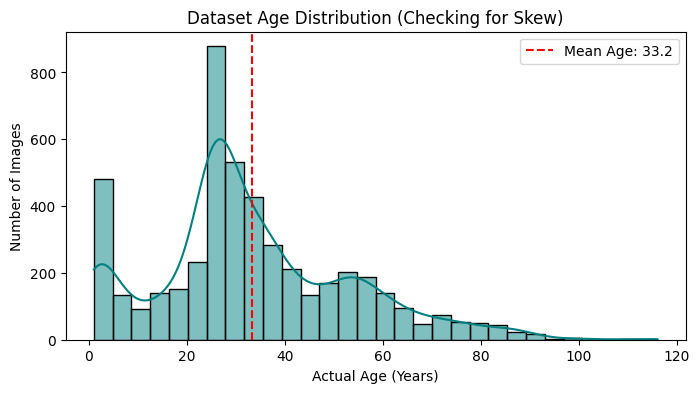

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(y_true_age, kde=True, color='teal', bins=30)
plt.axvline(np.mean(y_true_age), color='red', linestyle='--', label=f'Mean Age: {np.mean(y_true_age):.1f}')
plt.xlabel('Actual Age (Years)')
plt.ylabel('Number of Images')
plt.title('Dataset Age Distribution (Checking for Skew)')
plt.legend()
plt.show()